# NYC Public Design Commission Outdoor Public Art Analysis

## Getting Started

This notebook analyzes the NYC Public Design Commission Outdoor Public Art Inventory dataset to explore patterns in public art distribution, installation periods, and artistic mediums across New York City.

## Goals

- Load and explore the Public Design Commission Outdoor Public Art Inventory data
- Investigate spatial and temporal patterns in public art installations
- Visualize the distribution of art by medium, borough, and installation year
- Create both map and non-map visualizations to understand the data

## Import Libraries


In [1]:
# the bare minimum
import matplotlib.pyplot as plt  # for plotting
import geopandas as gpd  # for geospatial data handling
from matplotlib.lines import Line2D

# more advanced
from lonboard._map import Map
from lonboard._layer import PolygonLayer  # for mapping in 3D
from lonboard.colormap import (
    apply_categorical_cmap,
    apply_continuous_cmap,
)  # for assigning colors
from palettable.colorbrewer.sequential import PuRd_9  # for color palettes
from matplotlib.colors import LogNorm  # for logarithmic normalization
import pygwalker as pyg  # for creating interactive data visualizations

In [23]:
import os

print(os.getcwd())

/Users/jayce/datamapping/cdp_datamapping_system/cdp-mapping-systems/Assignments/01_Loading_visualizing


In [26]:
import os

os.path.exists(
    "../Data/Public_Design/Public_Design_Commission_Outdoor_Public_Art_Inventory_20250722.csv"
)

False

In [29]:
import pandas as pd
import geopandas as gpd

public_art = pd.read_csv(
    "../../Data/Public_Design/Public_Design_Commission_Outdoor_Public_Art_Inventory_20250722.csv"
)

In [8]:
pluto.head()

,geometry
0,"POLYGON ((980898.728 191409.779, 980881.798 19..."
1,"MULTIPOLYGON (((972428.829 190679.175, 972443...."
2,"POLYGON ((973648.066 193711.894, 973525.342 19..."
3,"POLYGON ((980609.55 194220.422, 980608.726 194..."
4,"POLYGON ((980854.138 194531.437, 980823.199 19..."


In [30]:
pluto.columns

Index(['geometry'], dtype='object')

In [31]:
list(pluto.dtypes)

In [35]:
# Direct access using absolute path
base_path = "/Users/jayce/datamapping/cdp_datamapping_system/cdp-mapping-systems"
data_path = f"{base_path}/Data"
print(f"Data folder check: {os.path.exists(data_path)}")

if os.path.exists(data_path):
    # Find Public_Design folder
    public_design_path = f"{data_path}/Public_Design"
    if os.path.exists(public_design_path):
        csv_files = [f for f in os.listdir(public_design_path) if f.endswith(".csv")]
        print("CSV files:", csv_files)

        if csv_files:
            file_path = f"{public_design_path}/{csv_files[0]}"
            public_art = pd.read_csv(file_path)
            print(f"Loading successful: {public_art.shape}")

Data folder check: True
CSV files: ['Public_Design_Commission_Outdoor_Public_Art_Inventory_20250722.csv']
Loading successful: (780, 43)


In [36]:
# Check basic data information
print(f"Public Art data size: {public_art.shape}")
print(f"Number of columns: {len(public_art.columns)}")

# Check first few rows
print("\nFirst 5 rows:")
public_art.head()

Public Art data size: (780, 43)
Number of columns: 43

First 5 rows:


,Title,Alternate Title,Primary Artist Last,Primary Artist First,Primary Artist Middle,Secondary Artist Last,Secondary Artist First,Secondary Artist Middle,Artists Keyword,Primary Architect Last,...,Borough,Subject Keyword,Inscription,Managing City Agency,Acquisition,PDC Records,Latitude,Longitude,Block,Lot #
0,Column of Jerash,Whispering Column of Jerash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Queens,"1964-65 World's Fair, antiquity",THIS COLUMN WAS PRESENTED TO/ THE NEW YORK WOR...,Department of Parks and Recreation,Gift of King Hussein of Jordan,NaN,40.746509,-73.842321,2018,1.0
1,Amiable Child Memorial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,"Children, tomb",West side of pedestal: ERECTED TO THE MEMORY /...,Department of Parks and Recreation,NaN,NaN,"40.814761,",-73.963162,1897,1.0
2,Fort George Memorial Tablet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,American Revolutionary War,TO PERPETUATE / THE SITE OF THE S.W. BASTION O...,Department of Parks and Recreation,Gift of the Corporation of the City of New York,NaN,40.703913,-74.014488,3,1.0
3,Firemen's Memorial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,Firefighters,THIS MONUMENT IS ERECTED / BY THE MEMBERS OF /...,Department of Parks and Recreation,Gift of Eagle Fire Company and Friends,2252,40.730092,-74.006382,582,1.0
4,Madison Square Fountain,Southern Fountain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,Fountain,THIS FOUNTAIN ORIGINALLY STOOD ON SITE OF OLD ...,Department of Parks and Recreation,NaN,1945,40.741722,-73.988297,852,1.0


In [40]:
print(f"Public Art data: {public_art.shape}")
public_art.head()

public_art.Borough.value_counts()

Public Art data: (780, 43)


Borough
Manhattan        369
Brooklyn         152
Queens           109
Bronx             86
Staten Island     64
Name: count, dtype: int64

In [38]:
# A great way to get a sense of a field is to look at
# the frequency of values in a categorical field.
# Here, we look at the Borough field, which describes the
# borough where each public artwork is located.
public_art.Borough.value_counts()

Borough
Manhattan        369
Brooklyn         152
Queens           109
Bronx             86
Staten Island     64
Name: count, dtype: int64

Borough
Manhattan        369
Brooklyn         152
Queens           109
Bronx             86
Staten Island     64
Name: count, dtype: int64


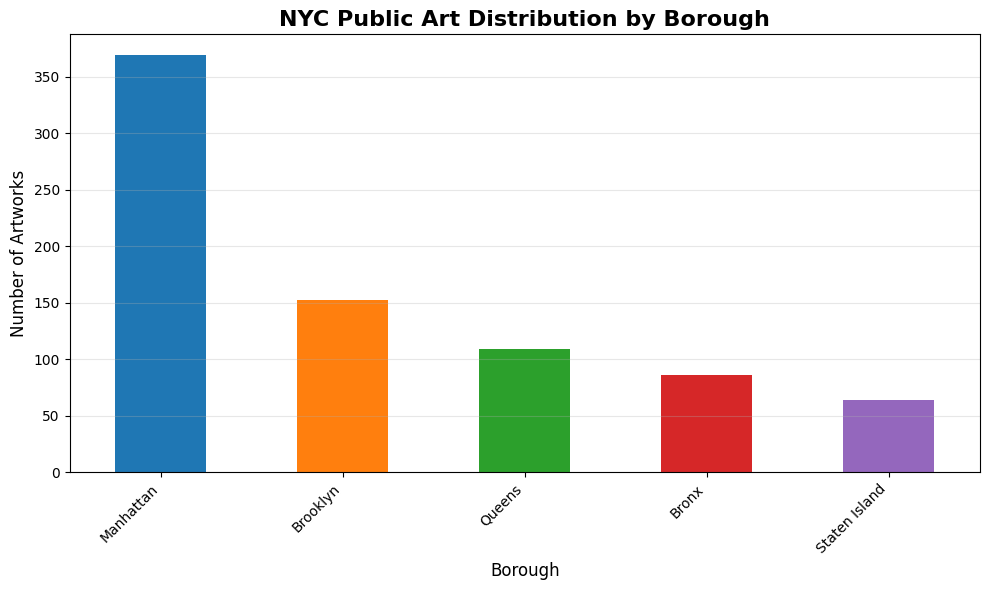

In [41]:
import matplotlib.pyplot as plt
import numpy as np

borough_counts = public_art["Borough"].value_counts()
print(borough_counts)

plt.figure(figsize=(10, 6))
borough_counts.plot(
    kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
)
plt.title("NYC Public Art Distribution by Borough", fontsize=16, fontweight="bold")
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Number of Artworks", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

We can "map" the Land Use codes to more descriptive names.
the `map()` function will replace instances of the "key" with the corresponding "value" in the dictionary.


In [46]:
public_art["Subject Keyword"].value_counts()

Subject Keyword
World War I, War                                56
Abstract                                        25
Animals, WPA                                    24
World War II, War                               22
Animals                                         15
                                                ..
Public Servant, United States Postal Service     1
Woman, Philanthropist                            1
Actor, World War I, War                          1
Literary Character, Children                     1
Maritime, Mythology, Roman mythology             1
Name: count, Length: 474, dtype: int64

In [47]:
public_art["Managing City Agency"].value_counts()

Managing City Agency
Department of Parks and Recreation                                                                      692
Department of Citywide Administrative Services                                                           21
Department of Transportation                                                                             16
Department of Design and Construction                                                                     8
Department of Environmental Protection                                                                    6
New York City Economic Development Corporation                                                            6
Department of General Services                                                                            5
Board of Education; School Construction Authority                                                         4
Brooklyn Botanic Garden                                                                                   3
New Yor

In [48]:
public_art["Primary Artist Last"].value_counts()

Primary Artist Last
Roth          41
Ward          12
MacMonnies     9
Keck           7
Diederich      6
              ..
de Filippo     1
Barthe         1
Ostrowski      1
Werner         1
Bergmann       1
Name: count, Length: 308, dtype: int64

In [49]:
public_art.groupby("Borough").size().sort_values(ascending=False)

Borough
Manhattan        369
Brooklyn         152
Queens           109
Bronx             86
Staten Island     64
dtype: int64

In [50]:
# more complex grouping
# We can also use the `agg()` function to apply multiple aggregation functions to different columns at once.
# For example, we can calculate the total artworks and unique artists for each borough:
borough_summary = (
    public_art.groupby("Borough")
    .agg({"Title": "count", "Primary Artist Last": "nunique"})
    .reset_index()
    .rename(
        columns={"Title": "Total Artworks", "Primary Artist Last": "Unique Artists"},
    )
)
borough_summary

,Borough,Total Artworks,Unique Artists
0,Bronx,86,36
1,Brooklyn,152,80
2,Manhattan,369,171
3,Queens,109,49
4,Staten Island,64,20


Now let's plot the total lot area for each land use type.


Text(0.5, 1.0, 'Total public artworks by borough')

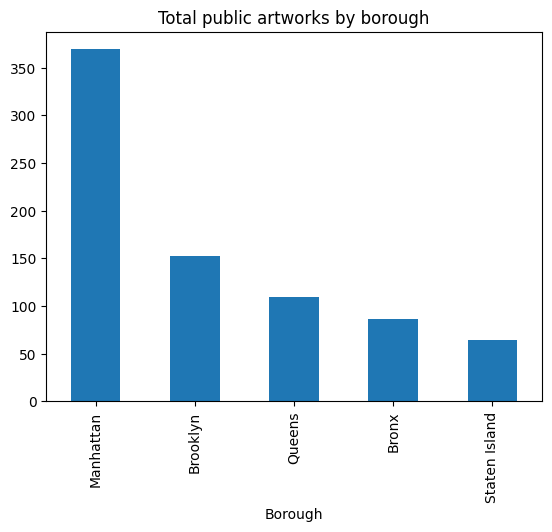

In [51]:
# there are many ways to visualize this data, and levels to refining the graphic style.
# This is the simplest possible example, using matplotlib to create a bar chart
import matplotlib.pyplot as plt

public_art.groupby("Borough").size().sort_values(ascending=False).plot.bar()
plt.title("Total public artworks by borough")

Text(0.5, 1.0, 'Number of unique artists by borough')

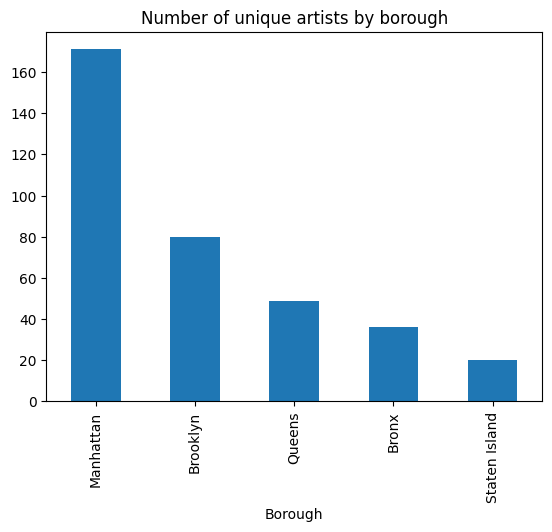

In [52]:
# now the same but for unique artists - note this is total unique artists, not average
public_art.groupby("Borough")["Primary Artist Last"].nunique().sort_values(
    ascending=False
).plot.bar()
plt.title("Number of unique artists by borough")

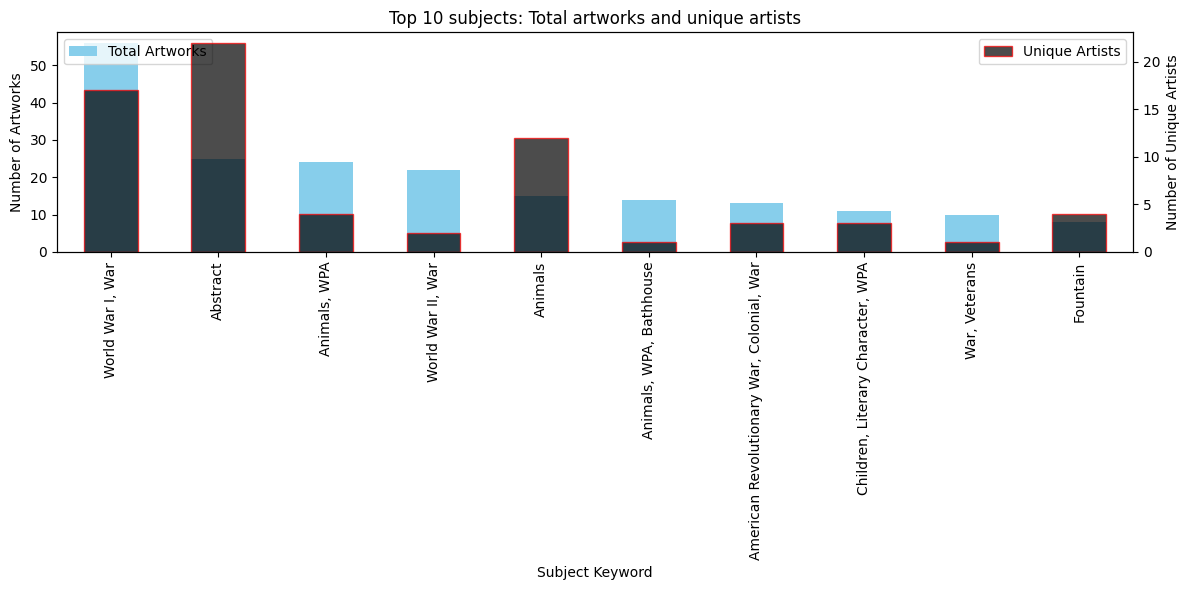

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
by_subject_count = (
    public_art.groupby("Subject Keyword").size().sort_values(ascending=False).head(10)
)

by_subject_count.plot.bar(ax=ax, color="skyblue")
ax.set_ylabel("Number of Artworks")
ax.set_xlabel("Subject Keyword")

ax2 = ax.twinx()
public_art.groupby("Subject Keyword")["Primary Artist Last"].nunique().reindex(
    by_subject_count.index
).plot.bar(ax=ax2, edgecolor="red", color="none", alpha=0.7)
ax2.set_ylabel("Number of Unique Artists")

plt.title("Top 10 subjects: Total artworks and unique artists")
ax.legend(["Total Artworks"], loc="upper left")
ax2.legend(["Unique Artists"], loc="upper right")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [54]:
public_art["Latitude"].describe()

count           780
unique          752
top       40.839942
freq             14
Name: Latitude, dtype: object

In [58]:
public_art["Latitude"] = pd.to_numeric(public_art["Latitude"], errors="coerce")

print("Latitude data after conversion:")
print(public_art["Latitude"].describe())
print("Data type:", public_art["Latitude"].dtype)

Latitude data after conversion:
count    748.000000
mean      40.735810
std        0.074758
min       40.514145
25%       40.693646
50%       40.742093
75%       40.776177
max       40.902662
Name: Latitude, dtype: float64
Data type: float64


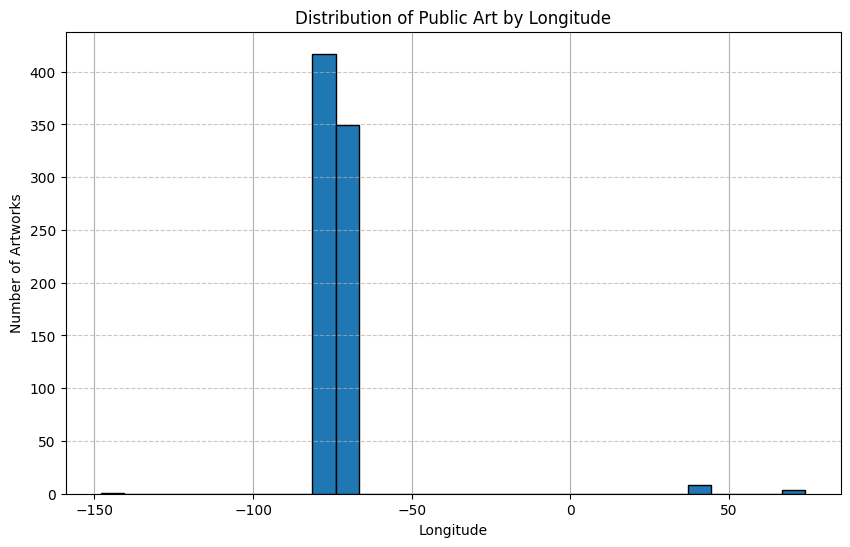

In [59]:
public_art["Longitude"] = pd.to_numeric(public_art["Longitude"], errors="coerce")

plt.figure(figsize=(10, 6))
public_art["Longitude"].hist(bins=30, edgecolor="black")
plt.title("Distribution of Public Art by Longitude")
plt.xlabel("Longitude")
plt.ylabel("Number of Artworks")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

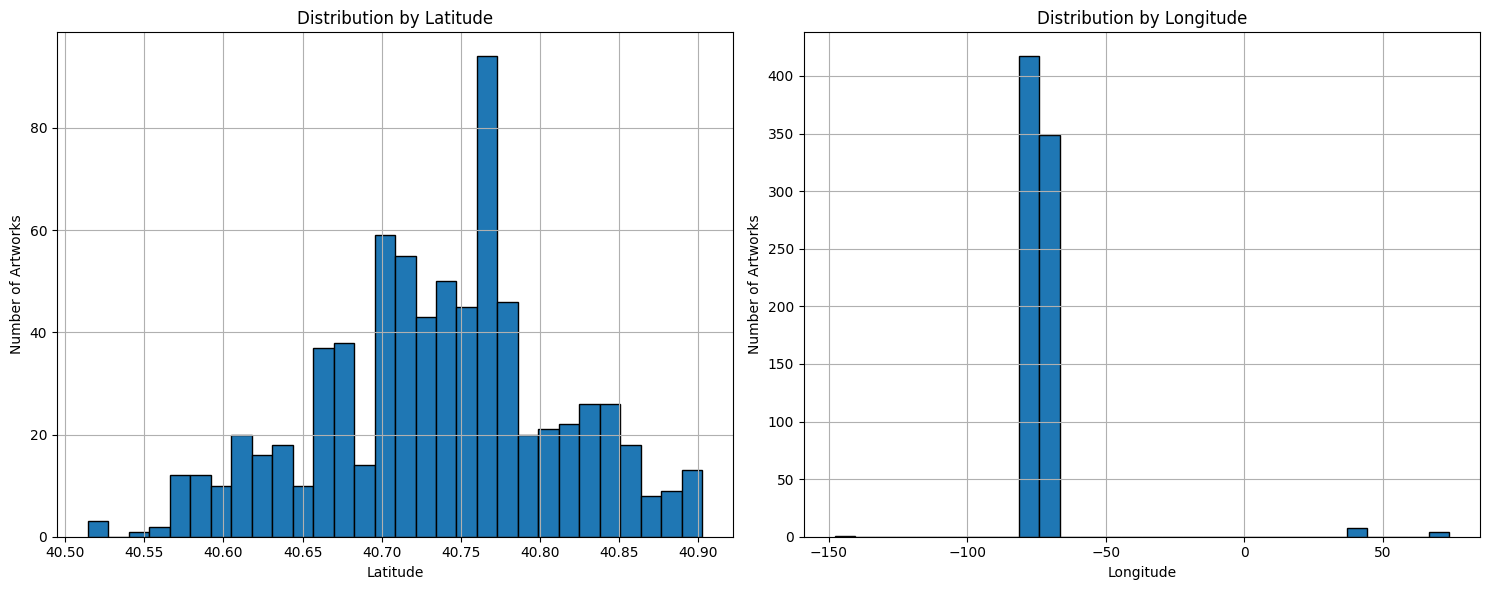

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

public_art["Latitude"].hist(bins=30, ax=ax1, edgecolor="black")
ax1.set_title("Distribution by Latitude")
ax1.set_xlabel("Latitude")
ax1.set_ylabel("Number of Artworks")

public_art["Longitude"].hist(bins=30, ax=ax2, edgecolor="black")
ax2.set_title("Distribution by Longitude")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Number of Artworks")

plt.tight_layout()
plt.show()

In [ ]:
import pygwalker as pyg

geometry_columns = [col for col in public_art.columns if "geometry" in col.lower()]
print("Geometry columns found:", geometry_columns)

if geometry_columns:
    public_art_non_spatial = public_art.drop(columns=geometry_columns)
else:
    public_art_non_spatial = public_art.copy()

pyg.walk(public_art_non_spatial)

Geometry columns found: []


Box(children=(HTML(value='\n<div id="ifr-pyg-00063c0914e27bd59XhDBngrCf0mMWE5" style="height: auto">\n    <hea…

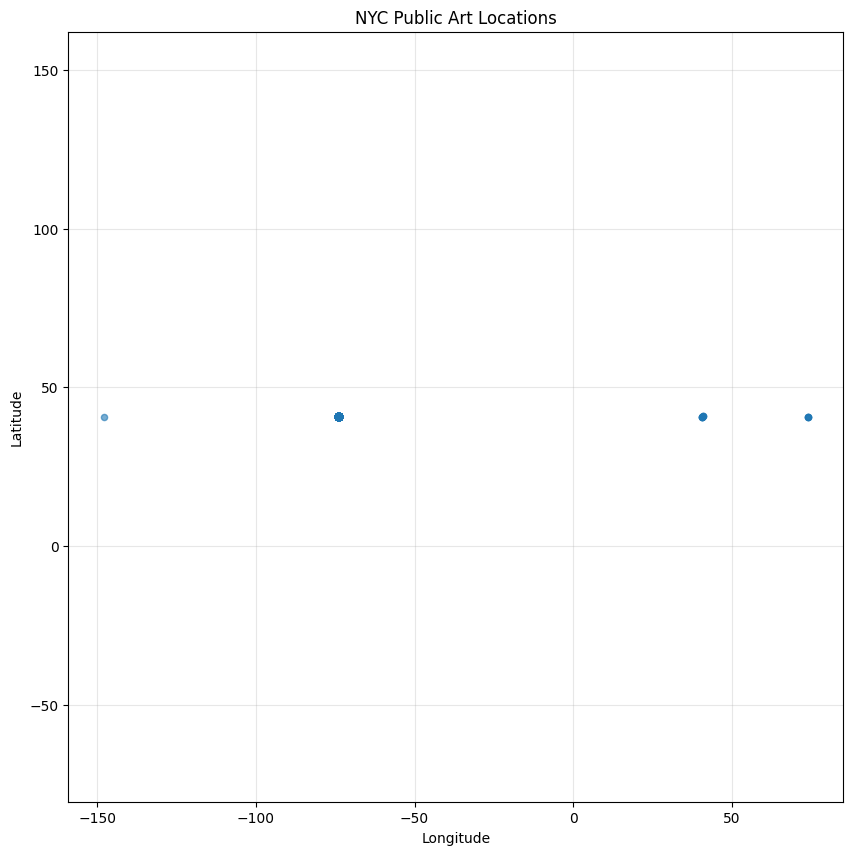

In [62]:
# In this example, we are using matplotlib to map our public art data.
# We'll create a scatter plot using latitude and longitude coordinates
# This shows the geographic distribution of public artworks across NYC

plt.figure(figsize=(10, 10))
plt.scatter(public_art["Longitude"], public_art["Latitude"], alpha=0.6, s=20)
plt.title("NYC Public Art Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

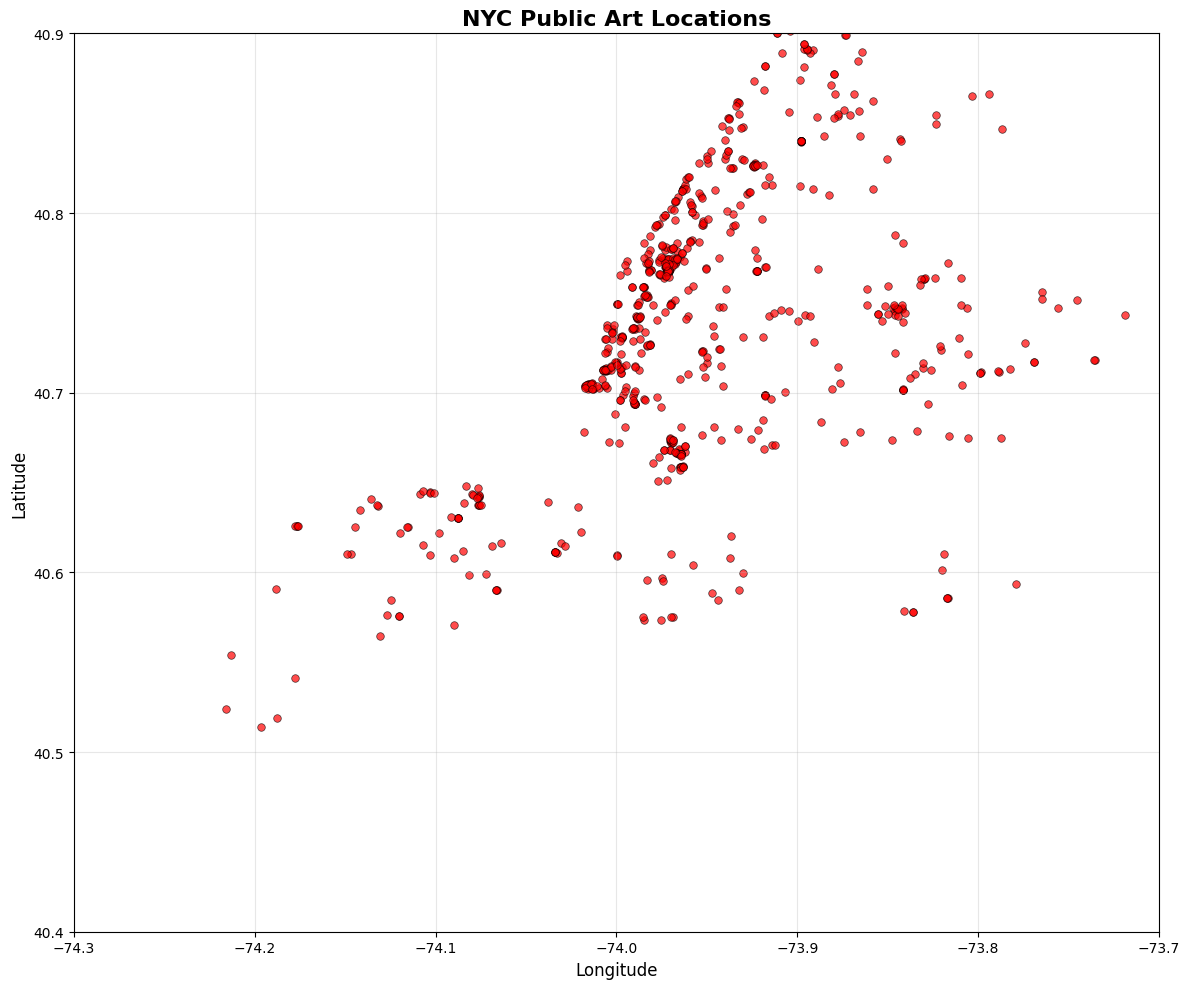

In [63]:
# Create a more polished map of public art locations
plt.figure(figsize=(12, 10))
plt.scatter(
    public_art["Longitude"],
    public_art["Latitude"],
    alpha=0.7,
    s=30,
    c="red",
    edgecolors="black",
    linewidth=0.5,
)
plt.title("NYC Public Art Locations", fontsize=16, fontweight="bold")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True, alpha=0.3)

# Set reasonable limits for NYC area
plt.xlim(-74.3, -73.7)
plt.ylim(40.4, 40.9)

plt.tight_layout()
plt.show()

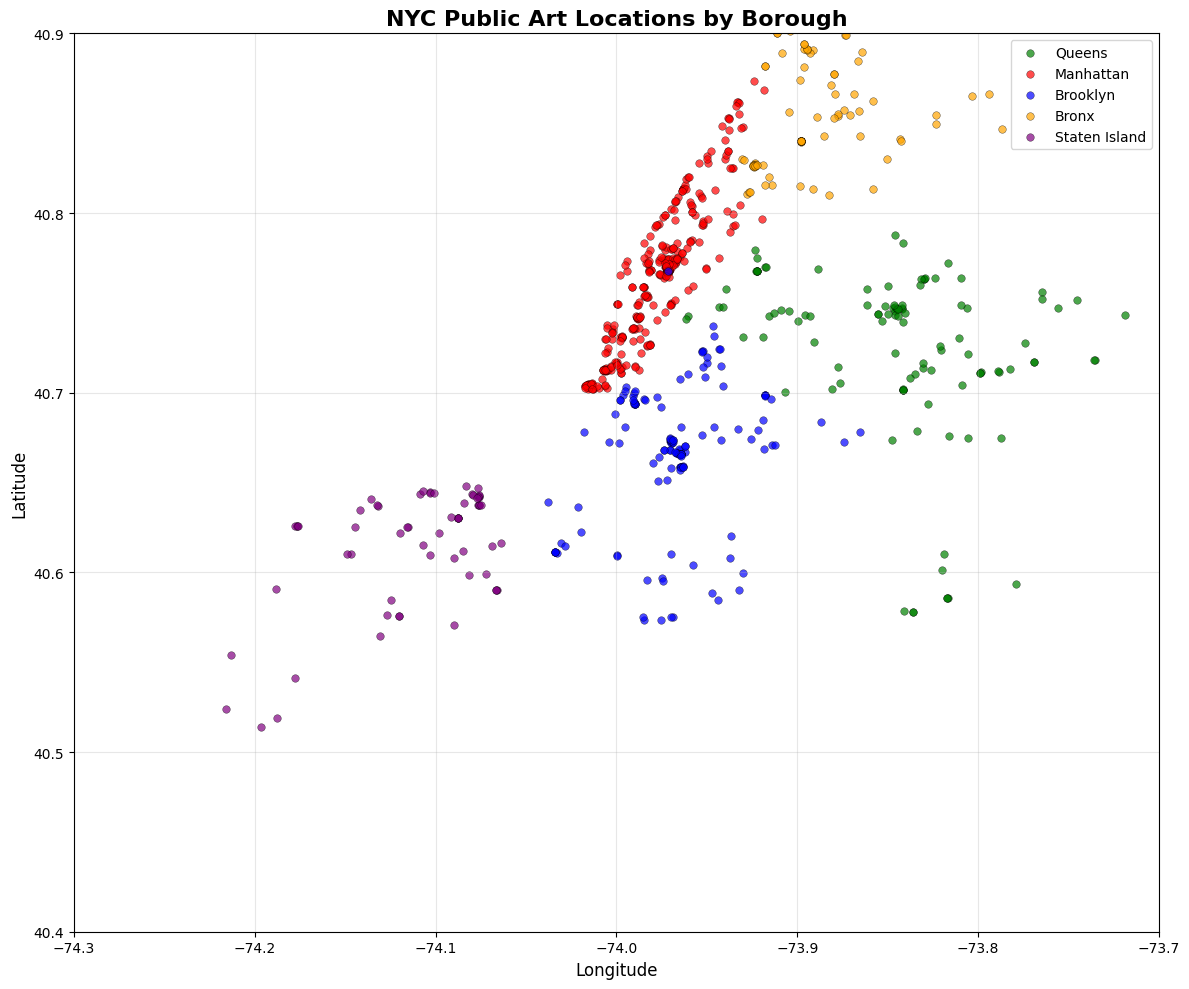

In [64]:
# Map with different colors for each borough
import matplotlib.pyplot as plt
import numpy as np

# Create color mapping for boroughs
borough_colors = {
    "Manhattan": "red",
    "Brooklyn": "blue",
    "Queens": "green",
    "Bronx": "orange",
    "Staten Island": "purple",
}

plt.figure(figsize=(12, 10))

for borough in public_art["Borough"].unique():
    if pd.notna(borough):
        borough_data = public_art[public_art["Borough"] == borough]
        plt.scatter(
            borough_data["Longitude"],
            borough_data["Latitude"],
            alpha=0.7,
            s=30,
            c=borough_colors.get(borough, "gray"),
            label=borough,
            edgecolors="black",
            linewidth=0.3,
        )

plt.title("NYC Public Art Locations by Borough", fontsize=16, fontweight="bold")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-74.3, -73.7)
plt.ylim(40.4, 40.9)
plt.tight_layout()
plt.show()

In [65]:
cmap = {
    "Manhattan": "#ff0000",
    "Brooklyn": "#0000ff",
    "Queens": "#00ff00",
    "Bronx": "#ff8000",
    "Staten Island": "#800080",
    "Unknown": "#808080",
}

In [67]:
public_art.fillna({"Borough": "Unknown"}, inplace=True)

In [68]:
public_art["Borough"].unique()

array(['Queens', 'Manhattan', 'Brooklyn', 'Bronx', 'Staten Island'],
      dtype=object)

In [69]:
# here we make a new column called "color" that maps the LandUse values to colors
public_art["color"] = public_art["Borough"].map(cmap)

In [71]:
public_art["color"].unique()

array(['#00ff00', '#ff0000', '#0000ff', '#ff8000', '#800080'],
      dtype=object)

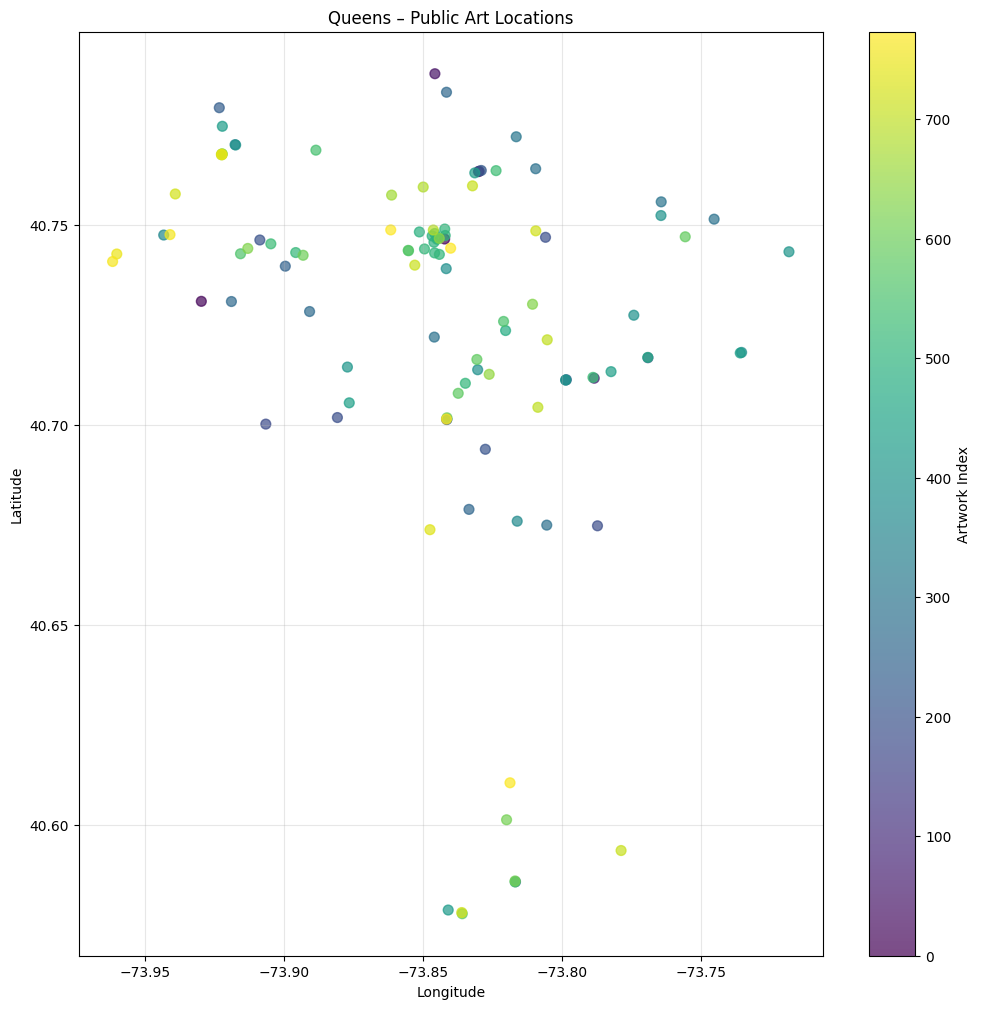

In [72]:
import matplotlib.pyplot as plt

queens = public_art[public_art["Borough"] == "Queens"]

fig, ax = plt.subplots(figsize=(12, 12))

# Create scatter plot using latitude and longitude
scatter = ax.scatter(
    queens["Longitude"],
    queens["Latitude"],
    c=queens.index,  # or use another numeric column for coloring
    cmap="viridis",
    s=50,
    alpha=0.7,
)

# Add colorbar
plt.colorbar(scatter, ax=ax, label="Artwork Index")

ax.set_title("Queens – Public Art Locations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
plt.show()

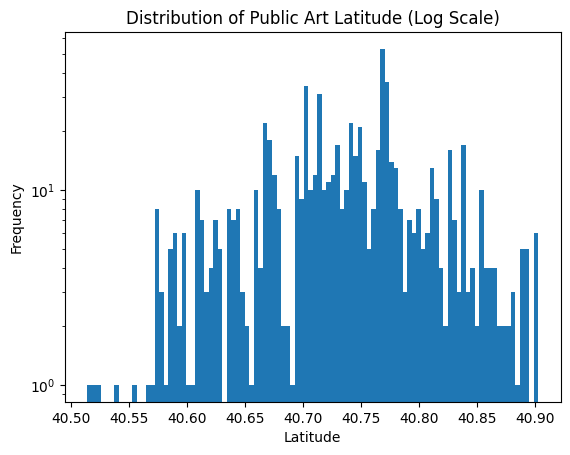

In [73]:
public_art["Latitude"].plot.hist(bins=100, log=True)
plt.title("Distribution of Public Art Latitude (Log Scale)")
plt.xlabel("Latitude")
plt.show()

In [74]:
import geopandas as gpd

# Create GeoDataFrame from latitude and longitude
public_art_wgs = gpd.GeoDataFrame(
    public_art,
    geometry=gpd.points_from_xy(public_art["Longitude"], public_art["Latitude"]),
    crs="EPSG:4326",  # WGS84 coordinate system
)

print(f"Created GeoDataFrame: {public_art_wgs.shape}")
print("CRS:", public_art_wgs.crs)

Created GeoDataFrame: (780, 46)
CRS: EPSG:4326


In [76]:
print("Longitude range:")
print(f"Min: {public_art['Longitude'].min()}")
print(f"Max: {public_art['Longitude'].max()}")

print("\nLatitude range:")
print(f"Min: {public_art['Latitude'].min()}")
print(f"Max: {public_art['Latitude'].max()}")

Longitude range:
Min: -147.986739
Max: 74.076476

Latitude range:
Min: 40.514145
Max: 40.902662


In [77]:
valid_coords = public_art[
    (public_art["Latitude"] >= 40.4)
    & (public_art["Latitude"] <= 40.9)
    & (public_art["Longitude"] >= -74.3)
    & (public_art["Longitude"] <= -73.7)
]

print(f"Valid coordinates: {len(valid_coords)} out of {len(public_art)}")

Valid coordinates: 730 out of 780


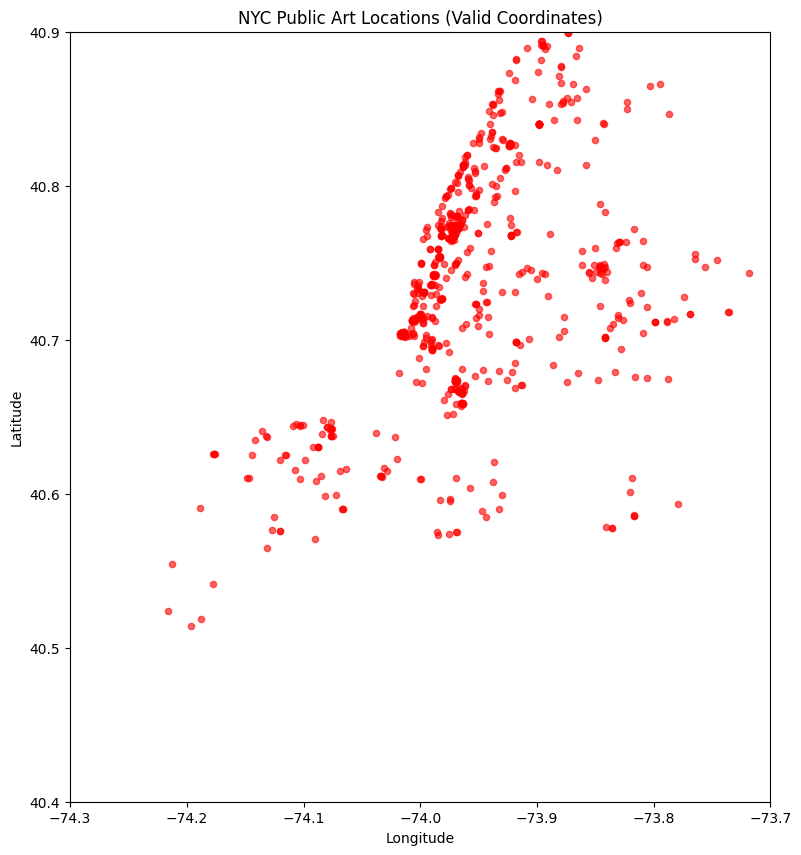

In [78]:
public_art_wgs = gpd.GeoDataFrame(
    valid_coords,
    geometry=gpd.points_from_xy(valid_coords["Longitude"], valid_coords["Latitude"]),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(12, 10))
public_art_wgs.plot(ax=ax, markersize=20, alpha=0.6, color="red")
ax.set_title("NYC Public Art Locations (Valid Coordinates)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_xlim(-74.3, -73.7)
ax.set_ylim(40.4, 40.9)
plt.show()

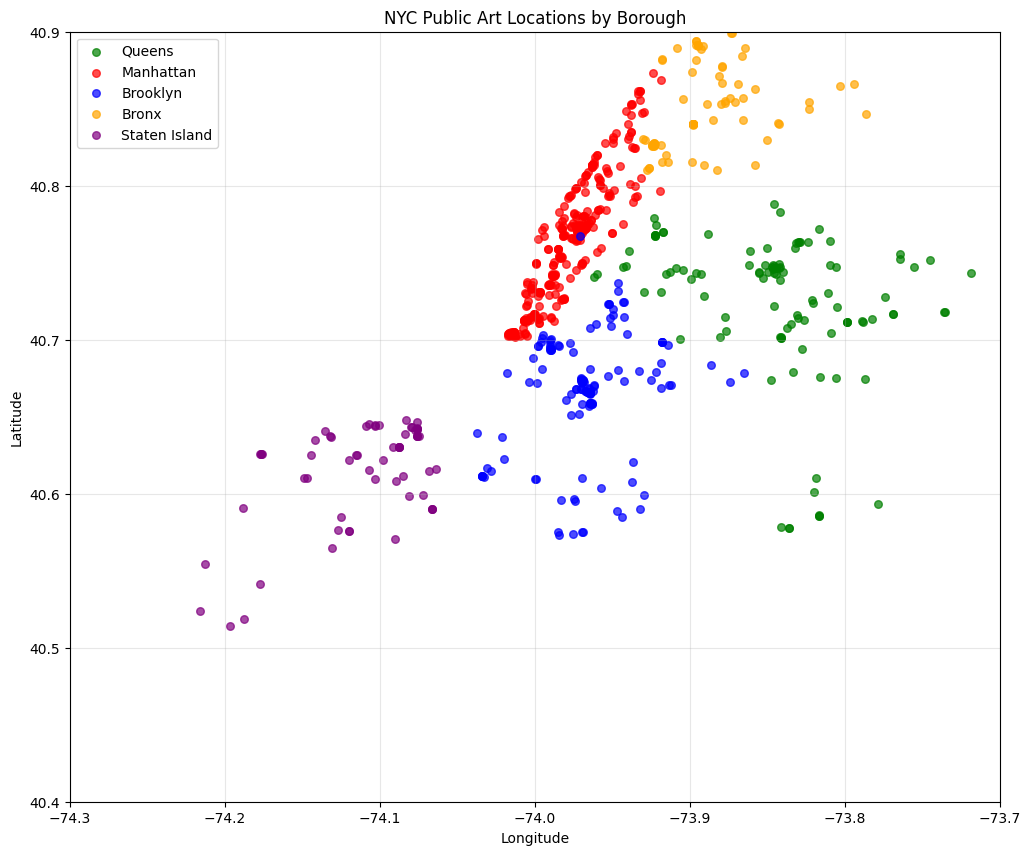

In [79]:
borough_colors = {
    "Manhattan": "red",
    "Brooklyn": "blue",
    "Queens": "green",
    "Bronx": "orange",
    "Staten Island": "purple",
}

fig, ax = plt.subplots(figsize=(12, 10))

for borough in valid_coords["Borough"].unique():
    if pd.notna(borough):
        borough_data = valid_coords[valid_coords["Borough"] == borough]
        ax.scatter(
            borough_data["Longitude"],
            borough_data["Latitude"],
            c=borough_colors.get(borough, "gray"),
            label=borough,
            alpha=0.7,
            s=30,
        )

ax.set_title("NYC Public Art Locations by Borough")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-74.3, -73.7)
ax.set_ylim(40.4, 40.9)
plt.show()

## visualize a categorical variable


In [80]:
cmap_rgb = {k: list(int(v[i : i + 2], 16) for i in (1, 3, 5)) for k, v in cmap.items()}

In [81]:
cmap_rgb

{'Manhattan': [255, 0, 0],
 'Brooklyn': [0, 0, 255],
 'Queens': [0, 255, 0],
 'Bronx': [255, 128, 0],
 'Staten Island': [128, 0, 128],
 'Unknown': [128, 128, 128]}

In [82]:
len(public_art_wgs[public_art_wgs["Borough"].isna()])

0

In [84]:
public_art.fillna({"Borough": "Unknown"}, inplace=True)

## now, we can plot the data using lonboard to create an interactive map


In [86]:
from lonboard import Map, ScatterplotLayer
from lonboard.colormap import apply_categorical_cmap

df = public_art_wgs[["Borough", "geometry"]].copy()
df["Borough"] = df["Borough"].astype("category")

layer = ScatterplotLayer.from_geopandas(
    df[["Borough", "geometry"]],
    get_fill_color=apply_categorical_cmap(
        df["Borough"],
        cmap=cmap_rgb,
    ),
    radius_scale=50,  # Adjust point size as needed
)

m = Map(layer)
m

Map(layers=[ScatterplotLayer(get_fill_color=<pyarrow.lib.FixedSizeListArray object at 0x3168b7640>
[
  [
    0…

In [87]:
public_art["Borough"].value_counts()

Borough
Manhattan        369
Brooklyn         152
Queens           109
Bronx             86
Staten Island     64
Name: count, dtype: int64

## visualize a continuous variable


In [88]:
from lonboard import Map, ScatterplotLayer
from lonboard.colormap import apply_continuous_cmap
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

df = public_art_wgs[["Borough", "geometry"]].copy()
df["artwork_index"] = range(len(df))  # Create index as continuous variable

normalizer = Normalize(0, len(df), clip=True)
normalized_index = normalizer(df.artwork_index)

layer = ScatterplotLayer.from_geopandas(
    df[["artwork_index", "geometry"]],
    get_fill_color=apply_continuous_cmap(normalized_index, cmap=get_cmap("PuRd")),
    radius_scale=50,
)

m = Map(layer)
m

/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_50735/979900464.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  get_fill_color=apply_continuous_cmap(normalized_index, cmap=get_cmap("PuRd")),


Map(layers=[ScatterplotLayer(get_fill_color=<pyarrow.lib.FixedSizeListArray object at 0x316a1c880>
[
  [
    2…

In [94]:
from lonboard import Map, ScatterplotLayer
from lonboard.colormap import apply_continuous_cmap
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

df = public_art_wgs[["Borough", "geometry"]].copy()
df["artwork_index"] = range(len(df))

normalizer = Normalize(0, len(df), clip=True)
normalized_index = normalizer(df.artwork_index)

layer = ScatterplotLayer.from_geopandas(
    df[["artwork_index", "geometry"]],
    get_fill_color=apply_continuous_cmap(normalized_index, cmap=get_cmap("PuRd")),
    radius_scale=100,
)
m = Map(
    layer, view_state={"longitude": -73.97, "latitude": 40.73, "zoom": 10, "pitch": 45}
)
m

/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_50735/3862295830.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  get_fill_color=apply_continuous_cmap(normalized_index, cmap=get_cmap("PuRd")),


Map(layers=[ScatterplotLayer(get_fill_color=<pyarrow.lib.FixedSizeListArray object at 0x3178ecd00>
[
  [
    2…

In [100]:
import matplotlib as mpl

# ... (same code above until layer creation)

layer = ScatterplotLayer.from_geopandas(
    df[["Created_Year", "geometry"]],
    get_fill_color=apply_continuous_cmap(
        normalized_years, cmap=mpl.colormaps["PuRd"]  # New way
    ),
    radius_scale=100,
)
m = Map(layer)
m

Map(layers=[ScatterplotLayer(get_fill_color=<pyarrow.lib.FixedSizeListArray object at 0x3175a8400>
[
  [
    2…

In [101]:
public_art_wgs["Borough"].nunique()

5

In [102]:
def categorize_artworks(r):
    if pd.isna(r.Created_Year):
        return "Unknown"
    elif r.Created_Year < 1900:
        return "Pre-1900"
    elif r.Created_Year < 1950:
        return "1900-1950"
    elif r.Created_Year < 2000:
        return "1950-2000"
    else:
        return "Post-2000"

In [103]:
public_art_wgs["creation_period"] = public_art_wgs.apply(categorize_artworks, axis=1)

In [104]:
public_art_wgs.creation_period.value_counts()

creation_period
1900-1950    322
1950-2000    236
Pre-1900      80
Post-2000     80
Unknown       12
Name: count, dtype: int64

In [106]:
creation_period_cmap = {
    "Pre-1900": "[255,0,0]",
    "1900-1950": "#00ff00",
    "1950-2000": "#0000ff",
    "Post-2000": "#ff00ff",
    "Unknown": "#808080",
}

In [107]:
df = public_art_wgs[["creation_period", "geometry"]]

print()
print(df["creation_period"].unique())

cmap_rgb = {
    "Pre-1900": [255, 0, 0],
    "1900-1950": [0, 255, 0],
    "1950-2000": [0, 0, 255],
    "Post-2000": [255, 0, 255],
    "Unknown": [128, 128, 128],
}

layer = ScatterplotLayer.from_geopandas(
    df[["creation_period", "geometry"]],
    get_fill_color=apply_categorical_cmap(df["creation_period"], cmap=cmap_rgb),
    radius_scale=100,
)
m = Map(layer)
m


['Unknown' 'Pre-1900' '1900-1950' '1950-2000' 'Post-2000']


Map(layers=[ScatterplotLayer(get_fill_color=<pyarrow.lib.FixedSizeListArray object at 0x31791e800>
[
  [
    1…

To read more about `lonboard` and mapping in 3d, see here for some tips: https://developmentseed.org/lonboard/latest/examples/overture-maps/#imports
